In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1:  add in residence data from previous MHA project

In [7]:
df = pd.read_csv("all_clean_updated.csv")
df2 = pd.read_csv("mission_data_clean.csv")

In [16]:
print(len(df), len(df2))

48349 48349


In [8]:
fix_columns = ["name", "birth_place", "loc_served", "residence"]
for c in fix_columns:
    df2[c] = df2[c].apply(lambda x: str(x).replace("unknown", "nan"))


In [19]:
residence_data = {}
features = ["new_residence", "City", "County", "State", "Country"]

for i in range(len(df2)):
    cur_url = df2["url"].iloc[i]
    if not cur_url in residence_data:
        cur_features = []
        for f in features:
            cur_features.append(df2[f].iloc[i])
        residence_data[cur_url] = cur_features

data_dict = {
    "new_residence" : [],
    "City" : [],
    "County" : [],
    "State" : [],
    "Country" : []
}

for i in range(len(df)):
    cur_url = df["url"].iloc[i]
    if cur_url in residence_data:
        for j in range(len(features)):
            data_dict[features[j]].append(residence_data[cur_url][j])
    else:
        for j in range(len(features)):
            data_dict[features[j]].append("")        

for c in data_dict:
    df[c] = data_dict[c]


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48349 entries, 0 to 48348
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   name                        48349 non-null  object
 1   birth_place                 48296 non-null  object
 2   birth_place_state           44101 non-null  object
 3   birth_place_country         48296 non-null  object
 4   mission                     48349 non-null  object
 5   loc_served                  43361 non-null  object
 6   year                        48349 non-null  int64 
 7   type                        30108 non-null  object
 8   residence                   47051 non-null  object
 9   url                         48349 non-null  object
 10  familysearch_links          48277 non-null  object
 11  parent1_bio                 48026 non-null  object
 12  parent2_bio                 48039 non-null  object
 13  parent1_birthplace          48112 non-null  ob

In [23]:
df.to_csv("birth_and_residence_data.csv", index = False)

### Task 2:  Classify liklihood of language learning per mission served

In [2]:
df = pd.read_csv("duration_data.csv")
df["mission"] = df["mission"].apply(lambda x: str(x).strip())

In [3]:
lds_mission_languages = {
    "Argentine Mission": ["Spanish"],
    "Armenian Mission": ["Armenian", "Turkish"],
    "Australasian Mission": ["English"],
    "Australian Mission": ["English"],
    "Brazilian Mission": ["Portuguese", "German"],
    "British Mission": ["English", "Welsh"],
    "California Mission": ["English", "Spanish"],
    "Canadian Mission": ["English", "French"],
    "Carson Valley Mission": ["English"],
    "Central Pacific Mission": ["Japanese"], # japanese language mission in Hawaii
    "Central States Mission": ["English"],
    "Colorado Mission": ["English"],
    "Czechoslovak Mission": ["Czech", "Slovak", "German"],
    "Danish Mission": ["Danish"],
    "Danish-Norwegian Mission": ["Danish", "Norwegian"],
    "Early Church Mission: Asia": ["Chinese", "Japanese", "Korean"], # "English"], # though some may have preached in english, esp in India
    "Early Church Mission: Europe": ["English", "German", "French", "Italian"],
    "Early Church Mission: North America": ["English", "French"],
    "Early Church Mission: South America": ["Spanish", "Portuguese"],
    "East Central States Mission": ["English"],
    "East German Mission": ["German"],
    "East Indian Mission": ["Hindi", "English"],
    "Eastern States Mission": ["English"],
    "Elk Mountain Mission": [],
    "European Mission": ["English", "German", "French", "Dutch", "Italian"], # broken down by area served
    "French Mission": ["French"],
    "German Mission": ["German"],
    "German and Austrian Mission": ["German"],
    "Gibraltar Mission": ["English", "Spanish"],
    "Hawaiian Mission": ["Hawaiian"],
    "Hong Kong Mission": ["Cantonese"],
    "Iceland Mission": ["Icelandic"],
    "Indian Territory Mission": [],
    "Irish Mission": ["English", "Irish"],
    "Italian Mission": ["Italian"],
    "Jamaica Mission": ["English"],
    "Japan Mission": ["Japanese"],
    "Las Vegas Mission": ["English", "Spanish"],
    "Malta Mission": ["Maltese", "English"],
    "Mexican Mission": ["Spanish"],
    "Middle States Mission": ["English"],
    "Midwives and Nurses Mission": ["English"],
    "Montana Mission": ["English"],
    "Netherlands Mission": ["Dutch"],
    "New England Mission": ["English"],
    "New Zealand Mission": ["English", "Maori"],
    "North Central States Mission": ["English"],
    "Northern States Mission": ["English"],
    "Northwestern States (Great Lakes) Mission": ["English"],
    "Northwestern States (Pacific) Mission": ["English"],
    "Norwegian Mission": ["Norwegian"],
    "Palestine-Syrian Mission": ["Arabic", "Turkish"],
    "Salmon River Mission": [], # native american mission
    "Salt Lake Mission Home": ["English"],
    "Samoan Mission": ["Samoan"],
    "Scandinavian Mission": ["Danish", "Norwegian", "Swedish"],
    "Shoshone Mission": [],
    "Siam Mission": ["Thai"],
    "South African Mission": ["English", "Zulu", "Afrikaans"], #, "Dutch"],
    "South American Mission": ["Spanish", "Portuguese", "German"], # Adding German based on new notes
    "Southern States Mission": ["English"],
    "Southern Utah Mission": [], # native american mission
    "Southwestern States Mission": ["English", "Spanish"],
    "Spanish American Mission": ["Spanish"],
    "Swedish Mission": ["Swedish"],
    "Swiss Mission": ["German", "French"],
    "Swiss and German Mission": ["German", "French"],
    "Tahitian Mission": ["Tahitian", "French"],
    "Temple Square Mission": ["English", "Spanish", "French"],
    "Texas Mission": ["English", "Spanish"],
    "The Tabernacle Choir at Temple Square Mission": ["English"],
    "Tongan Mission": ["Tongan"],
    "Turkish Mission": ["Turkish"],
    "Unspecified Native American Mission": [], # native american mission
    "Welsh Mission": ["Welsh", "English"],
    "West German Mission": ["German"],
    "Western States Mission": ["English"],
    "White Mountain Mission": [] # native american mission
}

language_to_countries = {
    "Afrikaans": ["South Africa", "Zimbabwe"],
    "Arabic": ["Syria"],
    "Armenian": ["Armenia"],
    "Cantonese": ["China"],
    #"Cherokee": ["United States"], # filtering out native american languages
    "Chinese": ["China"],
    "Czech": ["Czechoslovakia"],
    "Danish": ["Denmark", "Faroe Islands"],
    "Dutch": ["Belgium", "Netherlands"],
    "English": [ # add south africa, zimbabwe, india, etc?
        "Australia",
        "Canada",
        "Channel Islands",
        "Gibraltar",
        "Hawaii",
        "Ireland",
        "Isle of Man",
        "Jamaica",
        "New Zealand",
        "Saint Vincent and the Grenadines",
        "United Kingdom",
        "United States"
    ],
    "Finnish": ["Finland"],
    "French": ["France", "Quebec", "Belgium", "Switzerland", "Luxembourg"],
    "German": ["Austria", "Germany", "Switzerland", "Luxembourg"],
    "Hawaiian": ["Hawaii"],
    "Hindi": ["India"],
    "Icelandic": ["Iceland"],
    "Irish": ["Ireland"],
    "Italian": ["Italy"],
    "Japanese": ["Japan"],
    "Korean": [],
    "Maltese": ["Malta"],
    "Maori": ["New Zealand"],
    "Norwegian": ["Norway"],
    "Portuguese": ["Brazil"],
    "Samoan": ["Samoa"],
    # "Shoshone": ["United States"],
    "Slovak": ["Czechoslovakia"],
    "Spanish": ["Mexico", "Spain", "Venezuela"],
    "Swedish": ["Sweden"],
    "Tahitian": [],
    "Thai": [],
    "Tongan": ["Tonga"],
    "Turkish": ["Turkiye"],
    "Welsh": ["United Kingdom"],
    "Zulu": ["South Africa", "Zimbabwe"]
}

In [4]:
# location served to language mapping

scandinavian_mission_location_to_language = {
    "Aalborg Conference": ["Danish"],
    "Aalborg Conference, Denmark": ["Danish"],
    "Aalborg Conference, Denmark; Norway": ["Danish", "Norwegian"],
    "Aalborg Conference, Denmark; mission office": ["Danish"],
    "Aalborg and Christiania Conferences; Traveling Elder": ["Danish", "Norwegian"],
    "Aarhus Conference": ["Danish"],
    "Aarhus Conference, Denmark": ["Danish"],
    "Aarhus and Copenhagen Conferences, Denmark": ["Danish"],
    "After laboring for awhile in Chicago, Illinois, ElderJorgensen then labored in Copenhagen, Denmark.": ["Danish"],

    "Bergen (Norway), Copenhagen, and Aarhus (Denmark)Conferences": ["Norwegian", "Danish"],
    "Bergen Conference, Norway; Aarhus Conference, Denmark": ["Norwegian", "Danish"],
    "Bergen and Stavenger Norway": ["Norwegian"],
    "Bergen, Norway; Aalborg, Denmark": ["Norwegian", "Danish"],

    "Bornholm Conference": ["Danish"],
    "Bornholm, Denmark": ["Danish"],
    "Brevig Conference, Norway": ["Norwegian"],
    "Brevig Conference; Norway": ["Norwegian"],

    "Christiana Conference, Norway; Copenhagen Conference, Denmark": ["Norwegian", "Danish"],
    "Christiania Conference": ["Norwegian"],
    "Christiania Conference, Norway": ["Norwegian"],
    "Christiania and Drammen, Norway": ["Norwegian"],

    "Copenhagan and Aalborg, Denmark": ["Danish"],
    "Copenhagen": ["Danish"],
    "Copenhagen Conference": ["Danish"],
    "Copenhagen Conference, Denmark": ["Danish"],
    "Copenhagen Conference, Denmark; Bergen Conference, Norway; Aarhus Conference, Denmark": ["Danish", "Norwegian"],
    "Copenhagen Conference; mission office": ["Danish"],
    "Copenhagen and Aarhus Conferences, Denmark": ["Danish"],
    "Copenhagen and Christiania Conferences": ["Danish", "Norwegian"],
    "Copenhagen and Skane Conferences": ["Danish", "Swedish"],
    "Copenhagen, Aarhus Denmark": ["Danish"],
    "Copenhagen, Denmark": ["Danish"],
    "Copenhagen, Denmark, district J": ["Danish"],
    "Copenhagen, Denmark;": ["Danish"],
    "Copenhagen, Hovedstaden, Denmark": ["Danish"],

    "Dalarna Branch, Stockholm Conference": ["Swedish"],
    "Danish-Norwegian Mission": ["Danish", "Norwegian"],

    "Denmark": ["Danish"],
    "Denmark & Norway": ["Danish", "Norwegian"],
    "Denmark - 1889": ["Danish"],
    "Denmark - Aalborg and Aarhus Conferences": ["Danish"],
    "Denmark and Norway": ["Danish", "Norwegian"],
    "Denmark, Norway": ["Danish", "Norwegian"],
    "Denmark, Skjernbra": ["Danish"],
    "Denmark, Stockholm": ["Danish", "Swedish"],
    "Denmark; Christiania and Drammen, Norway": ["Danish", "Norwegian"],

    "England And Scandinavia": ["Danish", "Norwegian", "Swedish"],
    "Europe Scan": ["Danish", "Norwegian", "Swedish"],
    "Europe Scandinavia": ["Danish", "Norwegian", "Swedish"],
    "Europe, Scandinavia": ["Danish", "Norwegian", "Swedish"],
    "Europe-Scandinavia": ["Danish", "Norwegian", "Swedish"],
    "Europe/Scandinavia": ["Danish", "Norwegian", "Swedish"],

    "European Mission, Norway": ["Norwegian"],

    "Falster and Lolland, Denmark": ["Danish"],
    "Falun, Dalarna, Sweden": ["Swedish"],

    "Finland": ["Finnish"],
    "Finland and Sweden": ["Finnish", "Swedish"],
    "Finland and Sweden.": ["Finnish", "Swedish"],

    "Fredericia, Denmark": ["Danish"],
    "Frederiksberg, Denmark": ["Danish"],
    "Fredricks Haven, Denmark": ["Danish"],

    "Goteborg Conference": ["Swedish"],
    "Goteborg Conference, Sweden": ["Swedish"],
    "Goteborg and Kalmar Conferences": ["Swedish"],
    "Goteborg, Sweden": ["Swedish"],

    "HjÃ¸rring Branch; Vendsyssel, Fredericia, and AarhusConferences": ["Danish"],

    "Iceland": ["Icelandic"],
    "Iceland Scandinavia": ["Icelandic", "Danish", "Norwegian", "Swedish"],

    "Kongsted, Denmark": ["Danish"],
    "Lollard, Denmark": ["Danish"],
    "Lund, Sweden": ["Swedish"],

    "Malmo Conference, Sweden": ["Swedish"],

    "Manitoba and Iceland": ["Icelandic"],

    "Moss, Norway": ["Norwegian"],
    "Naestved, Denmark and Christiana Conference Norway": ["Danish", "Norwegian"],

    "North Jutland and Aarhus Conferences": ["Danish"],
    "North Jutland, Denmark; Sweden": ["Danish", "Swedish"],

    "Norway": ["Norwegian"],
    "Norway & Denmark": ["Norwegian", "Danish"],
    "Norway and Sweden": ["Norwegian", "Swedish"],
    "Norway, Sweden": ["Norwegian", "Swedish"],

    "Scandinavia": ["Danish", "Norwegian", "Swedish"],
    "Scandinavia And Russia": ["Danish", "Norwegian", "Swedish"],
    "Scandinavia Denmark": ["Danish"],
    "Scandinavia, Norway": ["Danish", "Norwegian", "Swedish"],
    "Scandinavian": ["Danish", "Norwegian", "Swedish"],
    "Scandinavian Iceland": ["Icelandic", "Danish", "Norwegian", "Swedish"],

    "Skane": ["Swedish"],
    "Skane Conference": ["Swedish"],
    "Skane and Goteborg Conferences": ["Swedish"],

    "Stockholm": ["Swedish"],
    "Stockholm Conference": ["Swedish"],
    "Stockholm Conference, Sweden": ["Swedish"],
    "Stockholm and Skane Conferences": ["Swedish"],
    "Stockholm, Copenhagen": ["Swedish", "Danish"],
    "Stockholm, Sweden": ["Swedish"],

    "Sweden": ["Swedish"],
    "Sweden and Denmark": ["Swedish", "Danish"],
    "Sweden and Finland": ["Swedish", "Finnish"],
    "Sweden and Finland; Stockholm Conference": ["Swedish", "Finnish"],
    "Sweden, Denmark": ["Swedish", "Danish"],
    "Sweden, Finland and Russia": ["Swedish", "Finnish"],

    "Trondheim, Sør-Trøndelag, Norway": ["Norwegian"],
    "Ttondhjem Conference Norway": ["Norwegian"],

    "U.S. and Scandinavia": ["Danish", "Norwegian", "Swedish"],
    "Zealand, Denmark": ["Danish"]
}

danish_norwegian_mission_location_to_language = {
    "Aalborg Conference": ["Danish"],
    "Aalborg Conference, Denmark": ["Danish"],
    "Aalborg Conference, Denmark, as an assistant": ["Danish"],

    "Aarhus Conference, Denmark": ["Danish"],
    "Aarhus Conference, Norway": ["Norwegian"],
    "Aarhus, Denmark": ["Danish"],
    "Aarhus, Denmark Conference and as assistant to the President of theSilkeborg Branch": ["Danish"],

    "Bergen Conference": ["Norwegian"],
    "Bergen Conference, Denmark": ["Danish"],
    "Bergen Conference, Norway": ["Norwegian"],
    "Bergen, Norway": ["Norwegian"],

    "Christiana Branch": ["Norwegian"],
    "Christiania Branch": ["Norwegian"],
    "Christiania Conference": ["Norwegian"],
    "Christiania Conference, Norway": ["Norwegian"],
    "Christiania District": ["Norwegian"],
    "Christiania, Norway": ["Norwegian"],

    "Copenhagen Conference": ["Danish"],
    "Copenhagen Conference, Denmark": ["Danish"],
    "Copenhagen Conference, Denmark, as an assistant": ["Danish"],

    "Danish Norwegian Mission, Aalborg Conference": ["Danish", "Norwegian"],

    "Denmark": ["Danish"],
    "Denmark Aarhus Conference": ["Danish"],
    "Denmark; Norway": ["Danish", "Norwegian"],

    "Fredrikstad, Norway": ["Norwegian"],

    "KÃÂÃÂÃÂÃÂ¸benhavn, Denmark": ["Danish"],  # København
    "Naestved, Denmark": ["Danish"],

    "Norway": ["Norwegian"],
    "Norway - Trondhjem Conference": ["Norwegian"],

    "President of the Randers Branch, Denmark": ["Danish"],

    "Scandanavia": ["Danish", "Norwegian", "Swedish"],
    "Scandinavia": ["Danish", "Norwegian", "Swedish"],
    "Scandinavia, Denmark": ["Danish"],
    "Scandinavia, Denmark, Norway": ["Danish", "Norwegian"],
    "Scandinavia/Iceland": ["Danish", "Norwegian", "Swedish", "Icelandic"],

    "Scandinavian": ["Danish", "Norwegian", "Swedish"],
    "Scandinavian Icelandia": ["Danish", "Norwegian", "Swedish", "Icelandic"],

    "Sweden": ["Swedish"],

    "Tonsberg Branch": ["Norwegian"],

    "Trondhjem": ["Norwegian"],
    "Trondhjem Conference": ["Norwegian"],
    "Trondhjem Conference, Norway": ["Norwegian"],

    "ÃÂÃÂÃÂÃ¢ÂÂ¦lborg, Denmark": ["Danish"],  # Aalborg
    "ÃÂÃÂÃÂÃ¢ÂÂ¦rhus, Denmark": ["Danish"]   # Aarhus
}

welsh_locations = set([
    "Aberdare, Wales, Welsh Conference",
    "Abertillery, Wales, Welsh Conference",
    "Abertillery, Welsh Conference, Wales and Manchester Conference, England.",
    "Birmingham and Welsh Conferences",
    "Birmingham, Warwickshire, and Derbyshire conferences and Wales",
    "Brechfa, Carmarthenshire, Wales, Great Britain",
    "Bristol Conference, Cardiff Branch, Burnley Branch",
    "Bristol Conference, England and Welsh Conference, Wales",
    "Bristol Conference, England and Welsh Conference, Wales.",
    "Bristol Conference, England and Welsh District, Wales",
    "Bristol Conference, England and Welsh District, Wales.",
    "Bristol, England and Welsh District, Wales",
    "Cambria",
    "Cardiff District, Welsh Conference, Wales",
    "Cardiff, Wales, Welsh Conference",
    "Cardiff, Wales, Welsh Conference.",
    "Cardiff, Welsh District, Wales and Gloucester, Bristol Conference, England",
    "Cardiganshire and Carmarthenshire, Wales, Welsh Conference",
    "Cardiganshire and Carmarthenshire, Welsh Conference, Wales",
    "Cardiganshire, Carmarthenshire, and Pembrokeshire, Welsh Conference",
    "Cardiganshire, Wales",
    "Carmarthen District, Welsh Conference, Wales",
    "Carmarthen and Ystrad, Rhondda, Wales, Welsh Conference",
    "Carmarthen, Welsh Conference, Wales.",
    "Carmarthenshire and Glamorganshire, Wales, Welsh Conference.",
    "Carmarthenshire, South Wales",
    "Carmarthenshire, Wales, Welsh Conference",
    "Carmarthenshire, Wales, Welsh Conference.",
    "Carmarthenshire, Wales. Presided over Welsh Conference.",
    "Cornwall, Bristol Conference, England and Welsh Conference, Wales.",
    "Denbigh and Cardiff, Wales, Welsh Conference.",
    "Denbigh, Wales, Welsh Conference.",
    "Dolgellau, Welsh Conference, Wales",
    "England, Scotland and Wales",
    "England, Scotland, Ireland, Wales",
    "England/Wales",
    "Flintshire, Wales, Welsh Conference.",
    "Glamorgan Conference, Wales",
    "Glamorgan, Welsh Conference, Wales",
    "Glamorganshire, Wales, Welsh Conference.",
    "Glamorganshire, Welsh Conference, Wales",
    "Great Britain Wales",
    "Herefordshire Conference, England and Newport, Monmouthshire, Wales",
    "Hull, England and Rhondda, Wales.",
    "Isle of Man, Pembrokeshire, Wales, Gloucestershire and Herefordshire, England",
    "Leeds Conference, England and Welsh Conference, Wales.",
    "Leeds, England and Welsh Conference, Wales",
    "Liverpool Conference, England and Welsh Conference, Wales.",
    "Liverpool and Macclesfield, England; Cardiff, Aberdare, and Cwnbran, Wales",
    "Liverpool, England and South Wales, Welsh Conference",
    "Liverpool, England and Wales",
    "Llandyb\xc3\x83\x82\xc2\x92\xc3\x83\xc2\x86\xc3\xa2\xc2\x80\xc2\x99\xc3\x83\xc2\x82\xc3\x82\xc2\xabe, Hirwaun, and Merthyr Tydfil, Wales.",
    "Llanelly (Llanelli) and Merthyr Tydfil, Wales, WelshConference",
    "Llanelly, Neath, & Swansea, Welsh Conference, Wales and ManchesterConference, England",
    "Llangadock (Llangadog), Wales, Welsh Conference",
    "London and Norwich Conferences, England and Haverfordwest, Pembrokeshire in the Welsh Conference, Wales.",
    "Manchester Conference, England and Welsh Conference, Wales",
    "Merthyr Tydfil and Abertillery, Welsh Conference, Wales.",
    "Merthyr Tydfil, Glamorganshire, Wales",
    "Merthyr Tydfil, Wales, Welsh Conference",
    "Merthyr Tydfil, Welsh Conference, Wales.",
    "Merthyr Tydifil, Wales, Welsh Conference.",
    "Monmouthshire Conference",
    "Monmouthshire District, Welsh Conference, Wales.",
    "Montgomeryshire, Denbighshire, and Cardiff, Wales, Welsh Conference.",
    "Neath, Wales",
    "Neath, Wales, Welsh Conference and London, England Conference",
    "Newcastle Conference, England and Welsh Conference, Wales.",
    "Newport District, Welsh Conference, Wales",
    "Newport District, Welsh Conference, Wales and London Conference, England",
    "Newport, Wales & Scotland, President of the Scottish Conference.",
    "Newport, Wales, Welsh Conference and London ConferencePresident.",
    "Newport, Wales; Clerk and President of the Welsh Conference.",
    "Newport, Welsh Conference, Wales",
    "North Wales",
    "North Wales Conference",
    "Norwich Conference, England and Welsh Conference, Wales.",
    "Nottingham Conference, England and Welsh Conference, Wales",
    "Nottingham and Bristol Conferences, England and Welsh District, Wales",
    "Originally called to the United States but reassigned to theWelsh Conference, Wales.",
    "Pembrokeshire, Wales, Welsh Conference.",
    "Penarth, Welsh Conference, Wales",
    "Pontypridd District, Welsh Conference, Wales",
    "Pontypridd, Wales, Welsh Conference",
    "Porth, Wales, Welsh Conference.",
    "Presided over missionary work in Wales, Ireland, andScotland",
    "President of the Welsh Conference, Wales",
    "Rhondda, Welsh Conference, Wales.",
    "Saundersfoot and Cardiff, Welsh Conference, Wales.",
    "Sheffield, England and Glamorgan Conference, Wales.",
    "South Wales",
    "South Wales and Liverpool, England",
    "South Wales, Europe",
    "South Wales, Welsh Conference and Norwich Conference, England",
    "Southwest Wales, Welsh Conference",
    "Stroud, British Conference, England and Welsh District, Wales",
    "Swansea and Aberdard Districts, Welsh Conference, Wales",
    "Swansea and Aberdare Districts, Welsh Conference, WelshConference, Wales",
    "Swansea and Cardiff, Wales. President of Welsh Conference.",
    "Swansea, Wales, Welsh Conference",
    "United States and South Wales",
    "Wales",
    "Wales, Great Britain",
    "Wales, United Kingdom",
    "Wales, Welsh Conference",
    "Welsh Conference",
    "Welsh Conference, South Wales and Reading Conference,England.",
    "Welsh Conference, Wales",
    "Welsh Conference, Wales and England.",
    "Welsh Conference, Wales and Leeds Conference, England.",
    "Welsh Conference, Wales and Liverpool, Lancashire, and Shropshire, England.",
    "Welsh Conference, Wales and London Conference, England",
    "Welsh Conference, Wales and Nottingham Conference, England",
    "Welsh Conference, Wales and Nottingham Conference, England.",
    "Welsh Conference, Wales and Nottingham and Leeds Conferences, England",
    "Welsh Conference, Wales and the Manchester Conference, England.",
    "Welsh Conference, Wales, United Kingdom",
    "Welsh Conference, Wales.",
    "Welsh District president, Wales",
    "Welsh District, South Wales",
    "Welsh District, Wales",
    "Welsh District, Wales - Bristol Conference, England",
    "Welsh Mission, Wales",
    "Welsh and Birmingham Conferences",
    "Wiltshire, England and Welsh Conference, Wales.",
    "Ystrad, Rhondda, and Cardiff Districts, Welsh Conference,Wales."
])

outside_british_isles = {
    "Amsterdam and Den Haag, Holland" : ["Dutch"],
    "Denmark" : ["Danish"],
    "England & Sweden" : ["Swedish"],
    "England And Switzerland" : ["French", "German"],
    "England, Scandinavia" : ["Danish", "Norwegian", "Swedish"],
    "England, Sweden" : ["Swedish"],
    "England, Switzerland" : ["French", "German"],
    "England/Sweden" : ["Swedish"],
    "Great Britain Iceland" : ["Icelandic"],
    "Great Britain Scandinavia" : ["Danish", "Norwegian", "Swedish"],
    "Great Britain Switzerland" : ["French", "German"],
    "Great Britain, Scandinavia" : ["Danish", "Norwegian", "Swedish"],
    "Iceland Conference" : ["Icelandic"],
    "Swiss and German Mission" : ["German"],
    "U S, England, Switzerland & Germany" : ["German", "French"]
}

native_american_locations = set(['Catawba Indian Nation, South Carolina', 'Catawba Indian Nation, South Carolina Conference', 'Catawba Indian Nation, South Carolina Conference, Georgia\nDistrict', 'Catawba Indian Nation, South Carolina Conference; Florida, Ohio,\nand Atlanta Conferences', 'Catawba Indian Nation, South Carolina Conference; Florida, Ohio,and Atlanta Conferences', 'Cherokee Nation', 'Georgia Conference; Catawba Indian Nation, South Carolina Conference', 'Georgia and South Carolina Conferences; Catawba Indian Nation,\nSouth Carolina', 'Indian Territory Mission, to include Oklahoma, Kansas, Arkansas\nand Texas. Indian Territory Mission was renamed Southern States\nMission in March 1898.', 'New Mexico Indian Territory', 'North Alabama and South Carolina Conferences; Catawba Indian\nNation, South Carolina', 'Snowflake, Navajo, Arizona', 'South Carolina Conference; Catawba Indian Nation, South\nCarolina', 'South Carolina Conference; Catawba Indian Nation, SouthCarolina', 'South Carolina and Florida Conferences; Catawba Indian Nation,\nSouth Carolina', 'South Carolina and Kentucky Conferences; Catawba Indian Nation,\nSouth Carolina', 'South Western States, Indian Territory to include Oklahoma,Kansas, Arkansas and Texas', 'Southern States\nCatawba Indian Nation, South Carolina Conference', 'Southern States: Western South Carolina District, Catawba Indian\nBranch', 'Southwestern States Cherokee Conference', 'Southwestern States, Indian Territory to include Oklahoma,\nKansas, Arkansas and Texas', 'Southwestern States,Ã\x83Â\x83Ã¢Â\x80Â\x9aÃ\x83Â\x82Ã\x82Â\xa0 to include Arkansas, Kansas, OklahomaTerritory, Texas and Indian Territory.', 'Tennessee; Catawba Indian Nation, South Carolina Conference', 'Through the Territory Information From his life story Helping the Indians and publicspeaking', 'To the Lamanites'])

In [5]:
mission_classification = pd.read_csv("mission_region_classification.csv")
mission_classification_dict = {}
mission_language_category_dict = {}
mission_language_dict = {}


for i in range(len(mission_classification)):
    mission_classification_dict[mission_classification["mission"].iloc[i].strip()] = mission_classification["region"].iloc[i]
    mission_language_category_dict[mission_classification["mission"].iloc[i].strip()] = mission_classification["mission_language_category"].iloc[i]
    mission_language_dict[mission_classification["mission"].iloc[i].strip()] = mission_classification["mission_language"].iloc[i]


In [16]:
# from visualization_functions import *

"""
Exceptions to country mappings:
 -- residence
 -- Hawaiian mission (English since 1898)
 -- New Zealand mission (Maori since 1881)
 -- British mission, European mission, Scandinavian mission (check loc served)

"""

no = 0
child = 0
yes = 0

responses = []
mission_region = []
mission_language_category = []
mission_language = []

short_mission_dict = {}

for i in range(len(df)):
    birth_country = df["birth_place_country"].iloc[i]
    birth_state = df["birth_place_state"].iloc[i]

    parent1_birth_country = df["parent1_birthplace_country"].iloc[i]
    parent1_birth_state = df["parent1_birthplace_state"].iloc[i]
    parent2_birth_country = df["parent2_birthplace_country"].iloc[i]
    parent2_birth_state = df["parent2_birthplace_state"].iloc[i]

    residence_country = df["Country"].iloc[i]
    residence_state = df["State"].iloc[i]

    loc_served = str(df["loc_served"].iloc[i]).strip()

    cur_mission = df["mission"].iloc[i]
    cur_year = int(df["year"].iloc[i])

    # add mission region
    mission_region.append(mission_classification_dict[cur_mission])
    mission_language_category.append(mission_language_category_dict[cur_mission])
    mission_language.append(mission_language_dict[cur_mission])

    # map mission to country
    language_list = lds_mission_languages[cur_mission][:]
    if cur_mission == "Hawaiian Mission" and cur_year > 1929: #  changing from 1918 to 1930 as cutoff according to BYU source
        language_list.append("English")
        mission_language_category[-1] = "English"
        mission_language[-1] = "English"
    if cur_mission == "New Zealand Mission" and cur_year >= 1885: # changing from 1881 to 1885 according to BYU source
        language_list.remove("English")
    elif cur_mission == "New Zealand Mission" and cur_year < 1881:
        mission_language_category[-1] = "English"
        mission_language[-1] = "English"        
        
    # check location served
    if cur_mission == "European Mission":
        if loc_served == "Belgium Austria":
            language_list = ["French", "German"]
            mission_language_category[-1] = "German"
            mission_language[-1] = "German"
        if loc_served in ["Great Britain", "Great Britian", "Birmingham Conference"]:
            language_list = ["English"]
            mission_language_category[-1] = "English"
            mission_language[-1] = "English"
        if loc_served == "Europe And Germany":
            language_list = ["German"]
            mission_language_category[-1] = "German"
            mission_language[-1] = "German"
        if loc_served == "Great Britain, Switzerland, and Germany":
            language_list = ["German"] # just focusing on non-english componenet
            mission_language_category[-1] = "German"
            mission_language[-1] = "German"
        if "Hungary" in loc_served:
            language_list = [] # no matching profiles 

    if cur_mission == "Early Church Mission: Europe":
        if "Hungary" in loc_served or "Russia" in loc_served:
            language_list = [] # no matching profiles

    if cur_mission == "Scandinavian Mission":
        # filter by location for swedish, danish, norwegian, finnish
        if loc_served in scandinavian_mission_location_to_language:
            language_list = scandinavian_mission_location_to_language[loc_served]
    if cur_mission == "Danish-Norwegian Mission":
        if loc_served in danish_norwegian_mission_location_to_language:
            language_list = danish_norwegian_mission_location_to_language[loc_served]
            
    # Check scandinavian mission splits like the danish-norwegian mission?

    if cur_mission == "British Mission":
        if cur_year < 1864 and loc_served in welsh_locations:
            language_list = ["Welsh"] # emphasizing welsh language 
        elif loc_served in outside_british_isles:
            language_list = outside_british_isles[loc_served]
            if "German" in language_list:
                mission_language_category[-1] = "German"
                mission_language[-1] = "German"
            elif "Swedish" in language_list or "Icelandic" in language_list or "Danish" in language_list:
                mission_language_category[-1] = "Scandinavian Languages"
                mission_language[-1] = "Scandinavian Languages"
            else:
                mission_language_category[-1] = "Other European Languages"
                mission_language[-1] = "Other European Languages"
        else: # default language
            mission_language_category[-1] = "English"
            mission_language[-1] = "English"           

    if loc_served in native_american_locations:
        mission_language_category[-1] = "Native American Languages"
        mission_language[-1] = "Native American Languages"
        language_list = []

    language_countries = [] 
    for language in language_list:
        language_countries.extend(language_to_countries[language])
    language_countries = set(language_countries)

    language_learner = ""

    # FINE TUNE WITH EXCEPTIONS
      
    
    if birth_state in language_countries or birth_country in language_countries:
        language_learner = "No"
    elif residence_state in language_countries or residence_country in language_countries:
        language_learner = "No"
    elif parent1_birth_country in language_countries or parent1_birth_state in language_countries:
        language_learner = "Child of Native Speaker"
    elif parent2_birth_country in language_countries or parent2_birth_state in language_countries:
        language_learner = "Child of Native Speaker"
    elif pd.isnull(birth_country) and pd.isnull(residence_country) and pd.isnull(parent1_birth_country) and pd.isnull(parent2_birth_country):
         language_learner = "Missing Information" 
    else:
        language_learner = "Yes"   
    
    # Check for previous missions
    if not language_learner == "No":
        cur_url = df["url"].iloc[i]
        cur_mission_language = mission_language[i]

        index = i - 1
        while index >= 0 and df["url"].iloc[index] == cur_url:
            if df["mission"].iloc[index] == cur_mission or mission_language[index] == cur_mission_language:
                language_learner = "No"
                break
            index -= 1


    # CHECK MISSION DURATION
    if not df["number_of_months"].iloc[i] == "Unknown":
        cur_duration = int(df["number_of_months"].iloc[i])
        if 0 <= cur_duration and cur_duration < 6:
            if language_learner == "Yes":
                # print(df["year"].iloc[i], df["url"].iloc[i])
                cur_mission = df["mission"].iloc[i]
                if cur_mission in short_mission_dict:
                    short_mission_dict[cur_mission] += 1
                else:
                    short_mission_dict[cur_mission] = 1
                
                language_learner = "No"
    
    if language_learner == "No":
        no += 1
    elif language_learner == "Child of Native Speaker":
        child += 1
    elif language_learner == "Yes":
        yes += 1

    responses.append(language_learner)

print(no, child, yes)
print(round(no / len(df) * 100, 2), round((no + child) / len(df) * 100, 2), round(yes / len(df) * 100, 2))

df["language_learner"] = responses
df["mission_region"] = mission_region
df["mission_language_category"] = mission_language_category
df["mission_language"] = mission_language


# TEST CODE
for m in short_mission_dict:
    print(short_mission_dict[m], m)



39493 1805 7015
81.68 85.42 14.51
45 Swiss and German Mission
27 Hawaiian Mission
22 White Mountain Mission
31 Elk Mountain Mission
3 Tahitian Mission
10 French Mission
16 Netherlands Mission
3 Danish-Norwegian Mission
28 Mexican Mission
13 Salmon River Mission
15 New Zealand Mission
12 East German Mission
11 Indian Territory Mission
14 German and Austrian Mission
4 Unspecified Native American Mission
9 West German Mission
8 Samoan Mission
3 Las Vegas Mission
8 German Mission
3 Spanish American Mission
5 South American Mission
1 Norwegian Mission
5 Turkish Mission
1 Southern Utah Mission
2 Brazilian Mission
1 Swiss Mission
1 Italian Mission
2 Tongan Mission
1 Southern States Mission
3 Scandinavian Mission
1 Early Church Mission: North America
1 Central States Mission
1 Hong Kong Mission
1 Danish Mission
1 Argentine Mission
1 Swedish Mission


In [17]:
df.to_csv("language_classification.csv", index = False)

### Preliminary Visuals

In [3]:
df = pd.read_csv("language_classification.csv")
df["mission"] = df["mission"].apply(lambda x: str(x).strip())

In [10]:
print(set(list(df["mission_language_category"])))

{'Polynesian Languages', 'Middle Eastern Languages', 'Other European Languages', 'Japanese', 'Scandinavian Languages', 'Spanish and Portugese', 'Other Asian Languages', 'Native American Languages', 'Welsh', 'German', 'English'}


In [18]:
# How many duplicate missionaries are there in various language groups?
# Only a few within the Polynesian Languages group 

cur_lang = "Polynesian Languages"

df_lang = df[(df["mission_language_category"] == cur_lang) & (df["language_learner"] == "Yes")] 

print(len(df_lang))

print(len(set(list(df_lang["url"]))))




1861
1854


In [19]:
# Language-Learning Rates

language_groups = set(list(df["mission_language"]))

language_numbers = []

for lang in language_groups:
    df_lang = df[df["mission_language"] == lang]
    total_speakers = len(df_lang)
    df_learners = df[(df["mission_language"] == lang) & (df["language_learner"] == "Yes")]
    total_learners = len(df_learners)
    rate = round(total_learners / total_speakers * 100, 2)

    language_numbers.append((rate, total_learners, total_speakers, lang))
    

language_numbers.sort()
for x in language_numbers:
    total_learners, total_speakers, rate, lang = x
    

    print(lang, total_learners, total_speakers, rate)




English 0.07 24 35366
Welsh 1.67 1 60
Scandinavian Languages 12.56 456 3631
German 55.14 1999 3625
Other European Languages 68.35 920 1346
Spanish and Portugese 69.54 854 1228
Native American Languages 80.78 496 614
Other Asian Languages 83.33 10 12
Middle Eastern Languages 83.33 50 60
Hawaiian 86.83 646 744
Maori 92.14 727 789
Samoan 93.62 396 423
Tongan 94.67 71 75
Japanese 96.73 148 153
Tahitian 97.31 217 223


In [69]:
df[df["mission_language"] == "Other Asian Languages"].head()
# df_lang[df_lang["year"] < 1865].head()

,name,birth_place,birth_place_state,birth_place_country,mission,loc_served,year,type,residence,url,...,parent2_birthplace_country,new_residence,City,County,State,Country,language_learner,mission_region,mission_language_category,mission_language
1181,Edward Davis Wade,"Farmersville, Cattaraugus, New York, United St...",New York,United States,Hong Kong Mission,NaN,1853,Proselytizing,"South Cottonwood, Great Salt Lake, Utah Territ...",https://history.churchofjesuschrist.org/chd/in...,...,United States,"Murray, Salt Lake, Utah, United States",Murray,Salt Lake,Utah,United States,No,Asia,Other Asian Languages,Other Asian Languages
2287,Benjamin Franklin Dewey,"Westfield, Hampden, Massachusetts, United States",Massachusetts,United States,Siam Mission,Ceylon (Sri Lanka),1852,Proselytizing,NaN,https://history.churchofjesuschrist.org/chd/in...,...,United States,Unknown,NaN,NaN,NaN,NaN,No,Asia,Other Asian Languages,Other Asian Languages
8106,William Willes,"Woolwich, London, Kent, England, United Kingdom",England,United Kingdom,East Indian Mission,NaN,1851,Proselytizing,"England, United Kingdom",https://history.churchofjesuschrist.org/chd/in...,...,United Kingdom,"England, United Kingdom",NaN,NaN,England,United Kingdom,No,Asia,Other Asian Languages,Other Asian Languages
11794,Cyrus Culver Canfield,"Columbus, Franklin, Ohio, United States",Ohio,United States,Hong Kong Mission,China,1853,Proselytizing,NaN,https://history.churchofjesuschrist.org/chd/in...,...,United States,Unknown,NaN,NaN,NaN,NaN,No,Asia,Other Asian Languages,Other Asian Languages
15551,James Lewis,"Gorham, Cumberland, Maine, United States",Maine,United States,Hong Kong Mission,China,1852,Proselytizing,"Great Salt Lake City, Great Salt Lake, Utah Te...",https://history.churchofjesuschrist.org/chd/in...,...,United States,"Salt Lake City, Salt Lake, Utah, United States",Salt Lake City,Salt Lake,Utah,United States,No,Asia,Other Asian Languages,Other Asian Languages


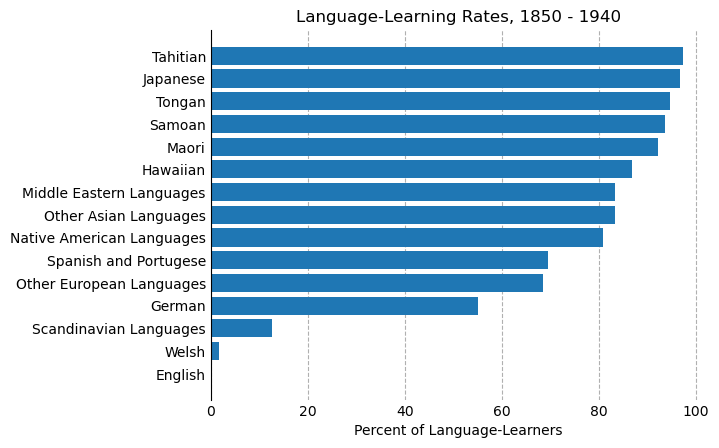

In [20]:
fig, ax = plt.subplots()

labels = [x[-1] for x in language_numbers]
values = [x[0] for x in language_numbers]
ax.barh(labels, values, zorder = 2)

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(axis = "both", length = 0)
ax.grid(axis = "x", linestyle = "--")

ax.set_title("Language-Learning Rates, 1850 - 1940")
ax.set_xlabel("Percent of Language-Learners")

plt.show()

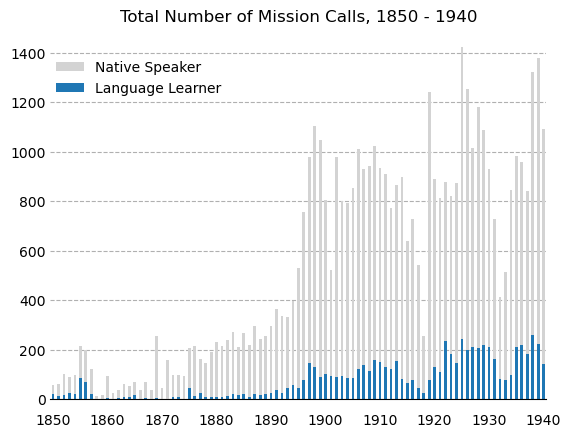

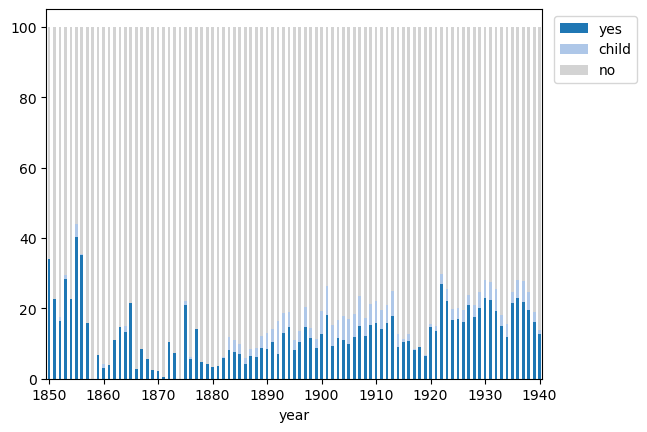

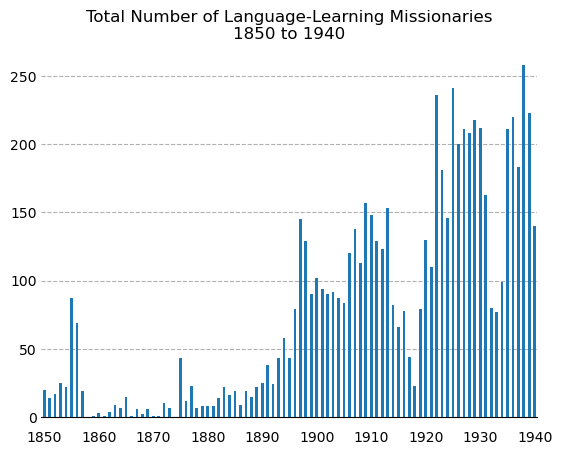

In [4]:
def get_language_counts(df):
    years = range(1850, 1941)
    no = {x : 0 for x in years}
    child = {x : 0 for x in years}
    yes = {x : 0 for x in years}

    for i in range(len(df)):
        cur_year = df["year"].iloc[i]
        if df["language_learner"].iloc[i] == "No":
            no[cur_year] += 1
        elif df["language_learner"].iloc[i] == "Yes":
            yes[cur_year] += 1
        else:
            child[cur_year] += 1

    no_list = [no[x] for x in years]
    child_list = [child[x] for x in years]
    yes_list = [yes[x] for x in years]
    data_dict = {"year": years, "yes": yes_list, "child": child_list, "no": no_list,}
    
    viz_df = pd.DataFrame(data_dict)
    viz_df = viz_df.set_index("year")

    # standard view
    fig, ax = plt.subplots()
    viz_df.plot.bar(stacked=True, ax = ax, rot = 0, color = [plt.cm.tab20(0), "lightgray", "lightgray"], zorder = 2)

    ax.legend(["Language Learner", "Native Speaker"], frameon = False, reverse = True, bbox_to_anchor=(0.37, 0.95))


    ax.set_xticks(range(0, 91, 10))

    ax.grid(axis = "y", linestyle = "--")
    ax.tick_params(axis = "both", length = 0)
    ax.spines[["top", "left", "right"]].set_visible(False)
    ax.tick_params(axis='x', pad=10)
    ax.set_xlabel("")

    ax.set_title("Total Number of Mission Calls, 1850 - 1940")
    
    plt.show()


    # proportional view

    proportion_df = viz_df.copy()
    columns = ["yes", "child", "no"]
    for c in columns:
        proportion_df[c] = proportion_df[c].astype('float')
    
    for i in range(len(proportion_df)):        
        total = proportion_df["no"].iloc[i] + \
                proportion_df["child"].iloc[i] + \
                proportion_df["yes"].iloc[i]
        
        if total > 0:
            for c in columns:
                proportion_df.loc[i + 1850, c] = (proportion_df[c].iloc[i] / total) * 100

    fig, ax = plt.subplots()

    proportion_df.plot.bar(stacked=True, ax = ax, rot = 0, color = [plt.cm.tab20(0), plt.cm.tab20(1), "lightgray"])

    ax.set_xticks(range(0, 91, 10))
    # ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.01, 1))

    
    plt.show()


    # Just language learners
    fig, ax = plt.subplots()

    viz_df.plot.bar(ax = ax, y = "yes", rot = 0, color = "tab:blue", legend = False, zorder = 10)

    ax.set_xticks(range(0, 91, 10))
    ax.grid(axis = "y", linestyle = "--", zorder = -10)
    ax.tick_params(axis = "both", length = 0)

    # ax.set_frame_on(False)
    # ax.axhline(0, color = "black")
    ax.spines[["top", "left", "right"]].set_visible(False)
    ax.tick_params(axis='x', pad=10)

    # cur_ylim = ax.get_ylim()
    # ax.set_ylim(cur_ylim[0] - 5, cur_ylim[1])
    ax.set_xlabel("")

    ax.set_title("Total Number of Language-Learning Missionaries\n1850 to 1940")

    plt.savefig('language_learner_totals.png')    
    plt.show()

    return viz_df

viz_df = get_language_counts(df)    

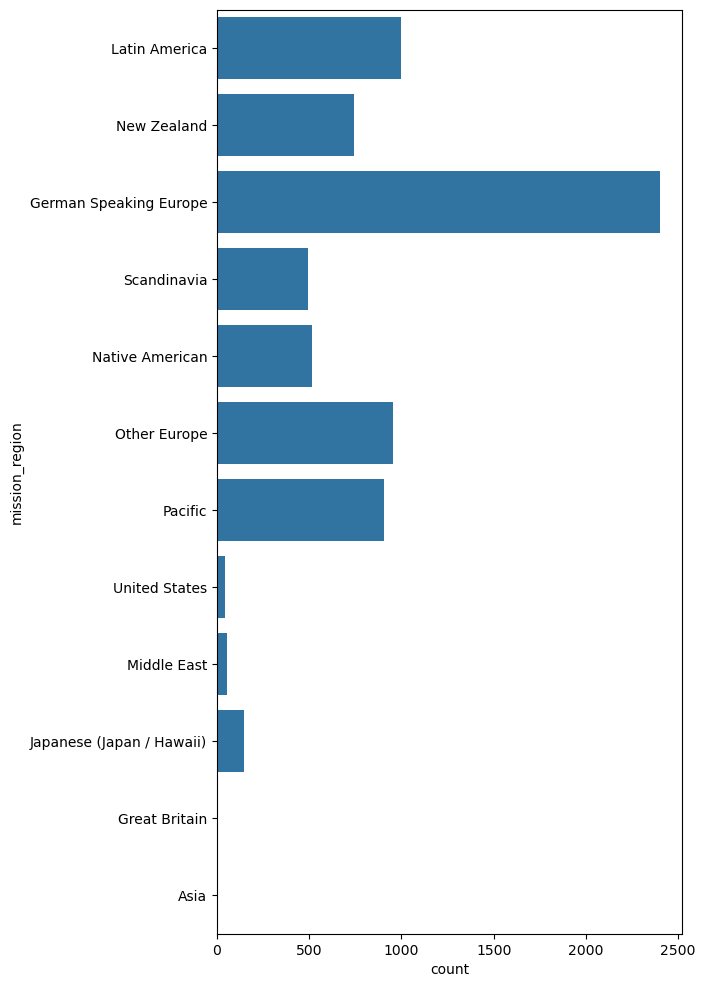

In [26]:
yes_df = df[df["language_learner"] == "Yes"]
fig, ax = plt.subplots(figsize=(6,12))
sns.countplot(yes_df, y="mission_region", ax = ax)

plt.show()

<Axes: xlabel='count', ylabel='mission_region'>

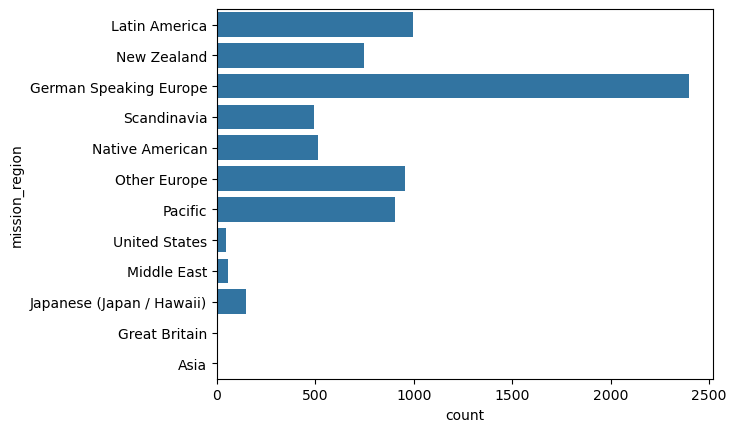

In [36]:
early_yes_df = yes_df[yes_df["year"] <= 1940]


sns.countplot(early_yes_df, y="mission_region")


### Scratch Work

In [6]:
language = "Hawaiian"

lang_df = df[df["mission_language"] == language]

# get missions 

mission_list = sorted(list(set(list(lang_df["mission"]))))
for m in mission_list:
    print(m)


print()

# get birth and parent countries
"""
country_list = list(lang_df["birth_place_country"])
country_list.extend(list(lang_df["parent1_birthplace_country"]))
country_list.extend(list(lang_df["parent2_birthplace_country"]))
country_list = [str(x) for x in country_list]

country_list = sorted(list(set(country_list)))

for c in country_list:
    print(c)
"""

print(len(lang_df))
print(len(list(set(lang_df["url"])))) # number of unique missionaries



"""
count = 0
for i in range(len(lang_df)):
    if str(lang_df["birth_place_country"].iloc[i]) == "Spain":
        count += 1
print(count)
"""




Hawaiian Mission

482
433


'\ncount = 0\nfor i in range(len(lang_df)):\n    if str(lang_df["birth_place_country"].iloc[i]) == "Spain":\n        count += 1\nprint(count)\n'

In [67]:
language = "Spanish and Portugese"

lang_df = df[(df["mission_language"] == language) & (df["language_learner"] == "No")]

lang_df.head(20)

,name,birth_place,birth_place_state,birth_place_country,mission,loc_served,year,type,residence,url,...,parent2_birthplace_country,new_residence,City,County,State,Country,language_learner,mission_region,mission_language_category,mission_language
45,Miel Carlson Pierce,"Levan, Juab, Utah Territory",Utah,United States,Mexican Mission,Mexico,1910,Proselytizing,"Colonia Diaz, Chihuahua, Mexico",https://history.churchofjesuschrist.org/chd/in...,...,Sweden,"Colonia Diaz, Chihuahua, Mexico",Colonia Diaz,NaN,Chihuahua,Mexico,No,Latin America,Spanish and Portugese,Spanish and Portugese
108,Wilson Walter Turley,"Colonia Juarez, Chihuahua, Mexico",NaN,Mexico,Mexican Mission,NaN,1939,NaN,Juarez Juarez,https://history.churchofjesuschrist.org/chd/in...,...,United States,"Juarez, Juarez, Chihuahua, Mexico",Juarez,Juarez,Chihuahua,Mexico,No,Latin America,Spanish and Portugese,Spanish and Portugese
433,Joseph Earl McClellan,"Pleasanton, New Mexico",New Mexico,United States,Spanish American Mission,NaN,1936,NaN,Mexican Mission,https://history.churchofjesuschrist.org/chd/in...,...,United States,United States,NaN,NaN,NaN,United States,No,United States,Spanish and Portugese,Spanish and Portugese
596,Simon Young Beck,"Spring City, Sanpete, Utah Territory, United S...",Utah,United States,Mexican Mission,Mexico,1906,NaN,"Colonia, Juarez, Mexico",https://history.churchofjesuschrist.org/chd/in...,...,United States,"Colonia Juarez, Chihuahua, Mexico",Colonia Juarez,NaN,Chihuahua,Mexico,No,Latin America,Spanish and Portugese,Spanish and Portugese
826,Abel Paez Bautista,"Atlantta, Chalco, Mexico",NaN,Mexico,Mexican Mission,NaN,1918,Proselytizing,NaN,https://history.churchofjesuschrist.org/chd/in...,...,Mexico,"Salt Lake City, Salt Lake, Utah, United States",Salt Lake City,Salt Lake,Utah,United States,No,Latin America,Spanish and Portugese,Spanish and Portugese
1034,Ami Lorenzo Anderson,"Colonia Diaz, Ascension, Chihuahua, Mexico",NaN,Mexico,Mexican Mission,Cuernavaca-Tlalpam,1909,Proselytizing,"Colonia Diaz, Chihuahua, Mexico",https://history.churchofjesuschrist.org/chd/in...,...,United States,"Colonia Diaz, Chihuahua, Mexico",Colonia Diaz,NaN,Chihuahua,Mexico,No,Latin America,Spanish and Portugese,Spanish and Portugese
1078,Joseph Lawrence Derbridge,"Ogden, Weber, Utah",Utah,United States,Mexican Mission,Mexican,1928,Proselytizing,"Salt Lake City, Salt Lake, Utah, United States",https://history.churchofjesuschrist.org/chd/in...,...,United States,"Salt Lake City, Salt Lake, Utah, United States",Salt Lake City,Salt Lake,Utah,United States,No,Latin America,Spanish and Portugese,Spanish and Portugese
1150,Arnold C Huber,"Payson, Utah, Utah",Utah,United States,Mexican Mission,Mexico,1910,Proselytizing,"Morelos, Sonora, Mexico",https://history.churchofjesuschrist.org/chd/in...,...,Switzerland,"Colonia Morales, Sonora, Mexico",Colonia Morales,NaN,Sonora,Mexico,No,Latin America,Spanish and Portugese,Spanish and Portugese
1749,Meliton Gonzalez Trejo,"Garganta la Olla, CÃÂÃÂÃÂÃÂ¡ceres, Extr...",NaN,Spain,Mexican Mission,"Arizona and Sonora, Mexico",1876,Proselytizing,"Richfield, Sevier, Utah Territory, United States",https://history.churchofjesuschrist.org/chd/in...,...,Spain,"Richfield, Sevier, Utah, United States",Richfield,Sevier,Utah,United States,No,Latin America,Spanish and Portugese,Spanish and Portugese
1750,Meliton Gonzalez Trejo,"Garganta la Olla, CÃÂÃÂÃÂÃÂ¡ceres, Extr...",NaN,Spain,Mexican Mission,NaN,1879,Proselytizing,"San Pedro, Pima, Arizona Territory, United States",https://history.churchofjesuschrist.org/chd/in...,...,Spain,"Richfield, Sevier, Utah, United States",Richfield,Sevier,Utah,United States,No,Latin America,Spanish and Portugese,Spanish and Portugese


In [5]:
# check loc served for various missions

mission = "Indian Territory Mission"

loc_served = set()
for i in range(len(df)):
    if df["mission"].iloc[i] == mission:
        loc_served.add(str(df["loc_served"].iloc[i]))


loc_served = sorted(list(loc_served))
# print(loc_served)

for x in loc_served:
    print(x)

Arizona, New Mexico
Arkansas and East Arkansas Conferences
Carson Valley Indian Territory
Cherokee
Cherokee Nation
Cherokee Nation Indian Territory
Cherokee, Choctaw, and Chickasaw Nations
Chickasaw Nation and Kansas Conference
Chickasaw Nation and St. John, Kansas
Colorado
Creek Nation and the Cherokee Nation
Deep Creek to the Lamanites
Independence, Marion, and other counties in Arkansas and in
Kansas City, Missouri.
Indian Territory
Indian Territory to include Oklahoma, Kansas, Arkansas and
Texas
Indian Territory, Oklahoma Conference
Indian Territory, St John Oklahoma Territory
Indian Territory; Texas Conference
Indians
Lamanites
Lower San Juan Valley
Malad Indian Farm - Washakie, Utah
Moquis Indians
New Mexico
South Western States
South Western States, Indian Territory to include Oklahoma,
Kansas, Arkansas and Texas
South Western States, Indian Territory to include Oklahoma, Kansas, Arkansas and Texas
South Western States, Indian Territory to include Oklahoma,Kansas, Arkansas and T

In [45]:
# check loc served for various missions

mission = "United States"
keywords = ["Indian", "Cherokee", "Navajo", "Lamanites"]

loc_served = set()
for i in range(len(df)):
    if df["mission_region"].iloc[i] == mission:
        for k in keywords:
            if k.lower() in str(df["loc_served"].iloc[i]).lower():
                cur_loc = str(df["loc_served"].iloc[i]).lower().replace("indiana", "")
                if k == "Indian" and "indian" in str(df["loc_served"].iloc[i]).lower().replace("indiana", ""):
                    loc_served.add(str(df["loc_served"].iloc[i]))
                elif not k == "Indian":
                    loc_served.add(str(df["loc_served"].iloc[i]))

loc_served = sorted(list(loc_served))
print(loc_served)

# for x in loc_served:
#     print(x)

['Catawba Indian Nation, South Carolina', 'Catawba Indian Nation, South Carolina Conference', 'Catawba Indian Nation, South Carolina Conference, Georgia\nDistrict', 'Catawba Indian Nation, South Carolina Conference; Florida, Ohio,\nand Atlanta Conferences', 'Catawba Indian Nation, South Carolina Conference; Florida, Ohio,and Atlanta Conferences', 'Cherokee Nation', 'Georgia Conference; Catawba Indian Nation, South Carolina Conference', 'Georgia and South Carolina Conferences; Catawba Indian Nation,\nSouth Carolina', 'Indian Territory Mission, to include Oklahoma, Kansas, Arkansas\nand Texas. Indian Territory Mission was renamed Southern States\nMission in March 1898.', 'New Mexico Indian Territory', 'North Alabama and South Carolina Conferences; Catawba Indian\nNation, South Carolina', 'Snowflake, Navajo, Arizona', 'South Carolina Conference; Catawba Indian Nation, South\nCarolina', 'South Carolina Conference; Catawba Indian Nation, SouthCarolina', 'South Carolina and Florida Conferenc

In [28]:
languages = set()

for x in lds_mission_languages:
    for y in lds_mission_languages[x]:
        languages.add(y)

for x in sorted(list(languages)):
    print(x)

Afrikaans
Arabic
Armenian
Cantonese
Cherokee
Chinese
Czech
Danish
Dutch
English
French
German
Hawaiian
Hindi
Icelandic
Irish
Italian
Japanese
Korean
Maltese
Maori
Norwegian
Portuguese
Samoan
Shoshone
Slovak
Spanish
Swedish
Tahitian
Thai
Tongan
Turkish
Welsh
Zulu
